In [1]:

from google.colab import files    #Habilitar unicamente si se ejecuta el codigo en google Colab
import os
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

files.upload()                    #Habilitar unicamente si se ejecuta el codigo en google Colab

os.listdir()

Saving pink_sheet.xlsx to pink_sheet.xlsx


['.config', 'pink_sheet.xlsx', 'sample_data']

In [2]:
ruta = "pink_sheet.xlsx"

In [3]:
# VISUALIZAR LOS DATOS DE LA HOJA SELECCIONADA
df = pd.read_excel(
    ruta,
    sheet_name="Annual Prices (Nominal)",
    skiprows=5, header=0
)

display(df.head(10))

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69
0,NaN,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
1,NaN,($/bbl),($/bbl),($/bbl),($/bbl),($/mt),($/mt),($/mmbtu),($/mmbtu),($/mmbtu),...,($/mt),($/dmtu),($/mt),($/mt),($/mt),($/mt),($/mt),($/troy oz),($/troy oz),($/troy oz)
2,1960.0,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,678.755833,198.85,2196.733333,1631,246.191667,35.27,83.5,0.9137
3,1961.0,1.57,1.57,1.57,…,…,…,0.15,0.404774,…,...,511.471832,11.02,633.084167,176.975,2449.891667,1711,214.308333,35.25,83.5,0.924442
4,1962.0,1.52,1.52,1.52,…,…,…,0.16,0.404774,…,...,498.060392,11.01,645.143333,155.283333,2471.383333,1761,185.925,35.23,83.5,1.083725
5,1963.0,1.5,1.5,1.5,…,…,…,0.16,0.391351,…,...,498.795265,11.02,645.950833,174.808333,2507.733333,1741.666667,211.508333,35.09,80.930833,1.279108
6,1964.0,1.45,1.45,1.45,…,…,…,0.15,0.38415,…,...,525.985631,10.24,969.753333,277.883333,3412.741667,1741.666667,326.491667,35.1,88.480833,1.293
7,1965.0,1.42,1.42,1.42,…,…,…,0.16,0.410766,…,...,540.131836,10.661667,1292.844167,317.175,3890.783333,1735,311.25,35.12,98.041667,1.293
8,1966.0,1.36,1.36,1.36,…,…,…,0.16,0.424929,…,...,540.131836,9.52,1531.513333,260.65,3573.508333,1739,281.108333,35.13,99.720833,1.293
9,1967.0,1.33,1.33,1.33,…,…,…,0.16,0.456647,…,...,540.131836,8.86,1134.7725,227.675,3308.025,1935.7,273.333333,34.95,110.248333,1.549183


In [4]:
# usar la primera fila como encabezados
df.columns = df.iloc[0]


In [5]:
# LIMPIAR ENCABEZADOS
df = df.drop(index=0).reset_index(drop=True)

In [6]:
# Renombrar la primera columna a 'año'
df.rename(columns={df.columns[0]: "año"}, inplace=True)

# Se borran las columnas "$/bbl"
df = df.drop(0)

# ESTABLECER "AÑO" COMO LA PRIMERA COLUMNA
df["año"] = pd.to_numeric(df["año"], errors="coerce")


In [7]:
# VER LOS ENCABEZADOS Y LAS PRIMERO 5 FILAS DE LA TABLA
df.head()

,año,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
1,1960.0,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,678.755833,198.85,2196.733333,1631,246.191667,35.27,83.5,0.9137
2,1961.0,1.57,1.57,1.57,…,…,…,0.15,0.404774,…,...,511.471832,11.02,633.084167,176.975,2449.891667,1711,214.308333,35.25,83.5,0.924442
3,1962.0,1.52,1.52,1.52,…,…,…,0.16,0.404774,…,...,498.060392,11.01,645.143333,155.283333,2471.383333,1761,185.925,35.23,83.5,1.083725
4,1963.0,1.5,1.5,1.5,…,…,…,0.16,0.391351,…,...,498.795265,11.02,645.950833,174.808333,2507.733333,1741.666667,211.508333,35.09,80.930833,1.279108
5,1964.0,1.45,1.45,1.45,…,…,…,0.15,0.38415,…,...,525.985631,10.24,969.753333,277.883333,3412.741667,1741.666667,326.491667,35.1,88.480833,1.293


In [8]:
# SELECCIONAR LOS CULTIVOS CON LOS QUE SE VA A TRABAJAR
df_cultivos = df[[
    "año",
    "Maize",
    "Coffee, Arabica",
    "Cocoa",
    "Sugar, world",
    "Soybeans"
]].copy()


In [9]:
df_cultivos.head()

,año,Maize,"Coffee, Arabica",Cocoa,"Sugar, world",Soybeans
1,1960.0,44.5,0.923517,0.589017,0.066208,91.833333
2,1961.0,44.956667,0.895542,0.478558,0.05945,109.333333
3,1962.0,48.653333,0.832592,0.457967,0.061683,100.54
4,1963.0,53.770833,0.805742,0.552342,0.183233,110.093333
5,1964.0,54.631667,1.009758,0.505742,0.126325,110.505833


In [10]:
# ESTABLECER TIPO DE DATO DE LAS COLUMNAS
for col in df_cultivos.columns[1:]:
    df_cultivos[col] = pd.to_numeric(df_cultivos[col], errors="coerce")


In [11]:
df_cultivos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 1 to 66
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   año              66 non-null     float64
 1   Maize            66 non-null     float64
 2   Coffee, Arabica  66 non-null     float64
 3   Cocoa            66 non-null     float64
 4   Sugar, world     66 non-null     float64
 5   Soybeans         66 non-null     float64
dtypes: float64(6)
memory usage: 3.2 KB


**PASO 1: REVISIÓN DE LA ESTRUCTURA DEL DATASET**

In [12]:
df_cultivos.info()
df_cultivos.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 1 to 66
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   año              66 non-null     float64
 1   Maize            66 non-null     float64
 2   Coffee, Arabica  66 non-null     float64
 3   Cocoa            66 non-null     float64
 4   Sugar, world     66 non-null     float64
 5   Soybeans         66 non-null     float64
dtypes: float64(6)
memory usage: 3.2 KB


,año,Maize,"Coffee, Arabica",Cocoa,"Sugar, world",Soybeans
1,1960.0,44.500000,0.923517,0.589017,0.066208,91.833333
2,1961.0,44.956667,0.895542,0.478558,0.059450,109.333333
3,1962.0,48.653333,0.832592,0.457967,0.061683,100.540000
4,1963.0,53.770833,0.805742,0.552342,0.183233,110.093333
5,1964.0,54.631667,1.009758,0.505742,0.126325,110.505833


**PASO 2: ESTADÍSTICA DESCRIPTIVA**

In [13]:
df_cultivos.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
0,,,,
año,1992.500000,19.196354,1960.000000,2025.000000
Maize,127.641212,64.858840,44.500000,318.806657
"Coffee, Arabica",2.741735,1.518642,0.805742,8.469378
Cocoa,1.929939,1.328272,0.365308,7.798072
"Sugar, world",0.249597,0.145868,0.039808,0.654817
Soybeans,291.983557,140.481186,91.833333,675.395000


**PASO 3: PREPARACIÓN PARA ANÁLISIS GRÁFICO**

In [14]:
df_long = df_cultivos.melt(
  id_vars = "año",
  var_name="cultivo",
  value_name="precio"
)

**PASO 4: ANÁLISIS TEMPORAL**

<function matplotlib.pyplot.show(close=None, block=None)>

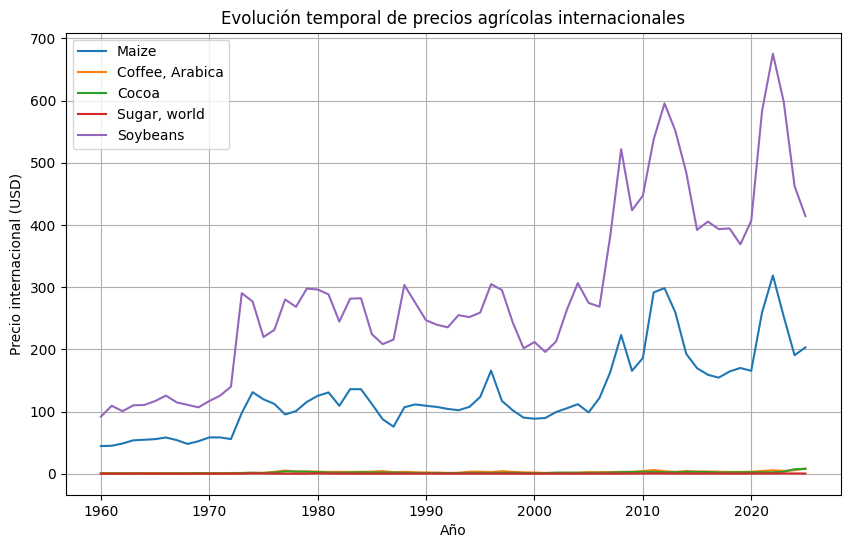

In [15]:
import matplotlib.pyplot as plt

from numpy import unique
plt.figure(figsize=(10, 6))

for cultivo in df_long["cultivo"].unique():
    data = df_long[df_long["cultivo"] == cultivo]
    plt.plot(data["año"], data["precio"], label=cultivo)

plt.xlabel("Año")
plt.ylabel("Precio internacional (USD)")
plt.title("Evolución temporal de precios agrícolas internacionales")
plt.legend()
plt.grid(True)
plt.show

**PASO 5: DISTRIBUCIÓN Y DISPERSIÓN**

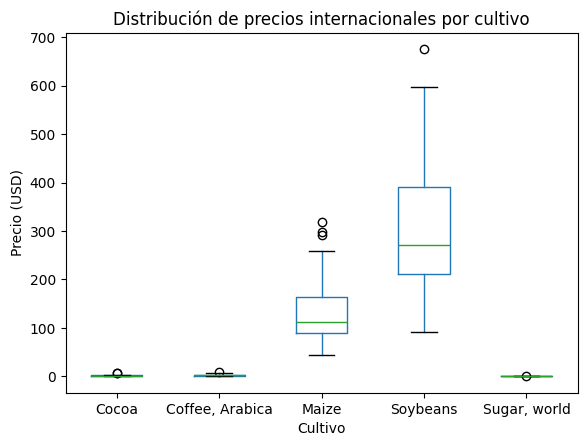

In [16]:
df_long.boxplot(column="precio", by="cultivo", grid=False)
plt.title("Distribución de precios internacionales por cultivo")
plt.suptitle("")
plt.xlabel("Cultivo")
plt.ylabel("Precio (USD)")
plt.show()

**PASO 6: MATRIZ DE CORRELACIÓN**

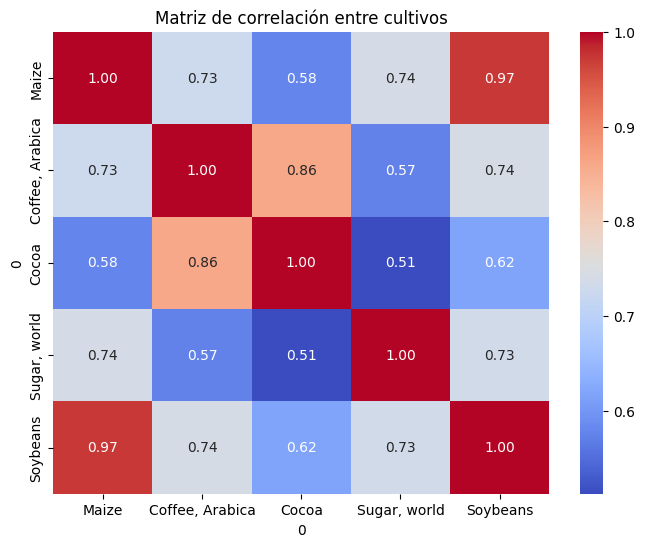

In [17]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df_cultivos.drop(columns="año").corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Matriz de correlación entre cultivos")
plt.show()

**PASO 7: VOLATILIDAD HISTORICA (RETORNO)**

In [18]:
df_returns = df_cultivos.copy()

for col in df_returns.columns[1:]:
    df_returns[col] = df_returns[col].pct_change()

df_returns.head()

,año,Maize,"Coffee, Arabica",Cocoa,"Sugar, world",Soybeans
1,1960.0,NaN,NaN,NaN,NaN,NaN
2,1961.0,0.010262,-0.030292,-0.187530,-0.102077,0.190563
3,1962.0,0.082227,-0.070293,-0.043029,0.037567,-0.080427
4,1963.0,0.105183,-0.032249,0.206074,1.970549,0.095020
5,1964.0,0.016009,0.253204,-0.084368,-0.310578,0.003747


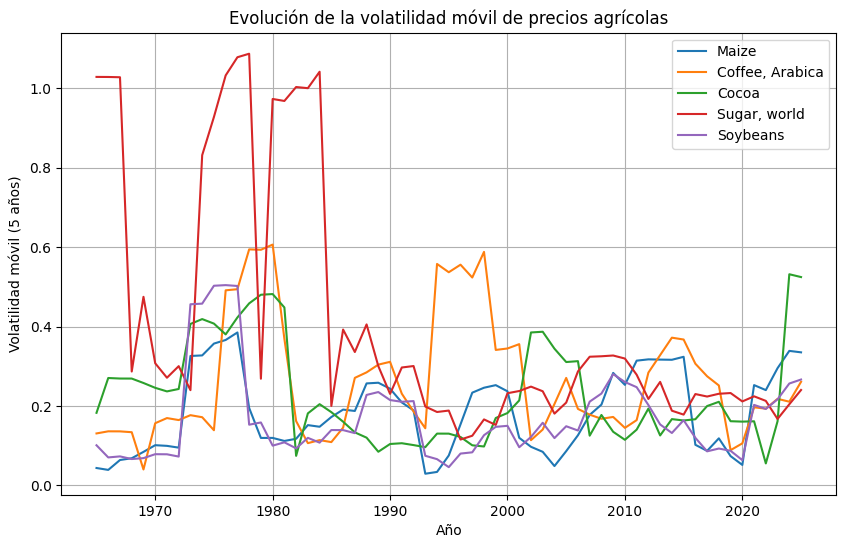

In [19]:
plt.figure(figsize=(10,6))

#Se calcula la desviación estandar de los retornos
rolling_vol = df_returns.drop(columns=["año"]).rolling(window=5).std()


for col in rolling_vol.columns:
    plt.plot(df_returns["año"], rolling_vol[col], label=col)

plt.xlabel("Año")
plt.ylabel("Volatilidad móvil (5 años)")
plt.title("Evolución de la volatilidad móvil de precios agrícolas")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print(df_cultivos.head())


0     año      Maize  Coffee, Arabica     Cocoa  Sugar, world    Soybeans
1  1960.0  44.500000         0.923517  0.589017      0.066208   91.833333
2  1961.0  44.956667         0.895542  0.478558      0.059450  109.333333
3  1962.0  48.653333         0.832592  0.457967      0.061683  100.540000
4  1963.0  53.770833         0.805742  0.552342      0.183233  110.093333
5  1964.0  54.631667         1.009758  0.505742      0.126325  110.505833


***ENTREGA 3: Modelo de Regresión Lineal por Cultivo***

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Lista de cultivos
cultivos = ["Maize", "Coffee, Arabica", "Cocoa", "Sugar, world", "Soybeans"]

resultados = []

for cultivo in cultivos:

    X = df_cultivos[["año"]]
    y = df_cultivos[cultivo]

    # División temporal 80-20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        "Cultivo": cultivo,
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)
    })

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados

,Cultivo,RMSE,R2
0,Maize,64.469,-0.455
1,"Coffee, Arabica",1.467,-0.023
2,Cocoa,1.922,-0.168
3,"Sugar, world",0.079,-0.212
4,Soybeans,121.799,-0.578
